<a href="https://colab.research.google.com/github/jfgs0303/Anal-tica-de-negocios/blob/main/DiabetesP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**INTRODUCCIÓN**

Una entidad del sector salud desea implementar un modelo analítico que permita clasificar pacientes según la presencia o ausencia de diabetes, a partir de variables clínicas y demográficas. Para ello se utiliza la base de datos Pima Indians Diabetes Database, la cual contiene información de pacientes y una variable objetivo denominada Outcome, que indica si el paciente presenta diabetes (1) o no presenta diabetes (0).

El objetivo de este trabajo es aplicar y comparar tres enfoques analíticos:

Naive Bayes

Árbol de Decisión

Clustering K-Means

A partir de estos modelos se busca analizar el comportamiento de las variables de entrada, evaluar el desempeño de cada técnica mediante matriz de confusión y métricas derivadas, e identificar cuál modelo sería más recomendable para el problema, considerando tanto el rendimiento cuantitativo como la interpretación desde el punto de vista del negocio y del sector salud.

Finalmente, se evaluará un paciente específico con las siguientes características:

XDp = [2,85,65,29,94,39.6,0.93,27]

con el fin de identificar el resultado arrojado por cada uno de los modelos.

**2. Carga de librerías**

In [ ]:
# Librerías numéricas y de manejo de datos
import numpy as np
import pandas as pd

# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de modelos
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, export_graphviz, export_text
from sklearn.cluster import KMeans

# Librerías de evaluación
from sklearn.metrics import confusion_matrix

# Librería para graficar el árbol
from pydotplus import graph_from_dot_data

**3. Carga de la base de datos y análisis exploratorio**

In [ ]:
# Cargar la base de datos desde el archivo csv
nxl = "/content/diabetes.csv"
XDB = pd.read_csv(nxl)

# Mostrar las primeras filas de la base
display(XDB.head(10))

# Mostrar número de observaciones y variables
print("Número de observaciones:", XDB.shape[0])
print("Número de variables:", XDB.shape[1])

# Mostrar tipo de dato de cada variable
print("\nTipos de datos:")
print(XDB.dtypes)

# Contar cuántos pacientes tienen y no tienen diabetes
print("\nConteo de la variable Outcome:")
print(XDB["Outcome"].value_counts())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


Número de observaciones: 768
Número de variables: 9

Tipos de datos:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Conteo de la variable Outcome:
Outcome
0    500
1    268
Name: count, dtype: int64


La base de datos contiene 768 observaciones y 9 variables.
La variable de salida es Outcome, donde:

0 indica que el paciente no presenta diabetes

1 indica que el paciente sí presenta diabetes

En la base se identifican:

500 pacientes sin diabetes

268 pacientes con diabetes

Todas las variables son numéricas, lo cual facilita la aplicación de los modelos de clasificación y agrupación.

**4. Análisis de correlación**

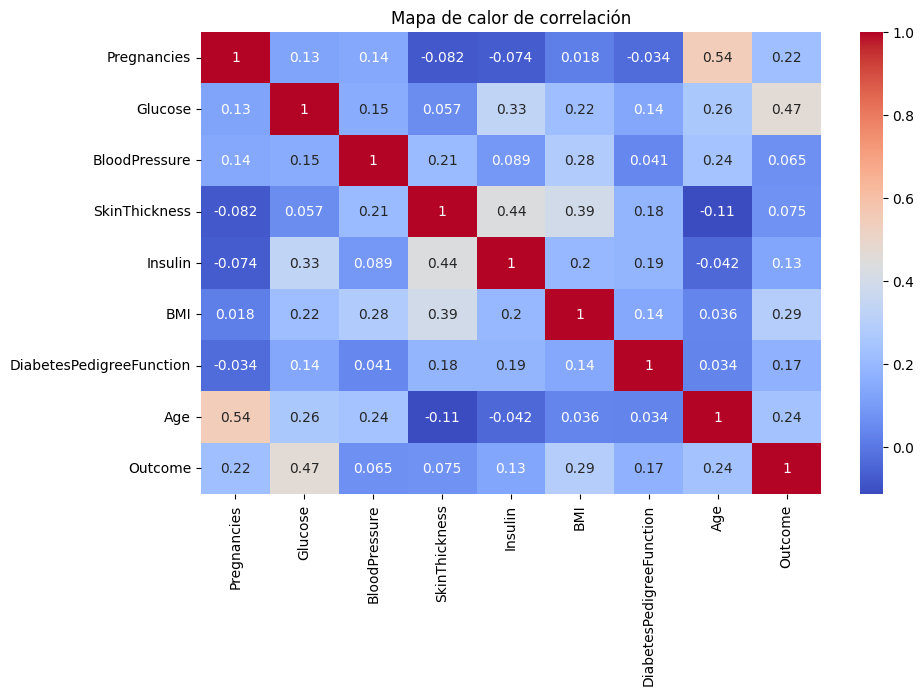

Correlación de las variables con Outcome:
Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


In [ ]:
# Crear una copia de la base para analizar correlación
XDB2 = XDB.copy()

# Construir mapa de calor con la matriz de correlación
plt.figure(figsize=(10,6))
sns.heatmap(XDB2.corr(), annot=True, cmap="coolwarm")
plt.title("Mapa de calor de correlación")
plt.show()

# Mostrar la correlación de cada variable con Outcome
corr_outcome = XDB2.corr()["Outcome"].sort_values(ascending=False)
print("Correlación de las variables con Outcome:")
print(corr_outcome)

A partir del mapa de calor se observa que la variable de entrada que presenta la mayor correlación con la variable de salida Outcome es Glucose, lo cual indica que el nivel de glucosa es el factor más relacionado con la presencia de diabetes.

Entre las variables de entrada, una de las correlaciones más importantes se presenta entre Pregnancies y Age, y también se observa una relación relevante entre SkinThickness e Insulin.

Desde el punto de vista del negocio y del análisis clínico, esto sugiere que variables como la glucosa, el índice de masa corporal y la edad son especialmente útiles para apoyar la clasificación de pacientes.

**5. Modelo Naive Bayes**



5.1 Selección de variables

In [ ]:
# Seleccionar variables de entrada
XD = XDB[['Pregnancies','Glucose','BloodPressure','SkinThickness',
          'Insulin','BMI','DiabetesPedigreeFunction','Age']]

# Seleccionar variable de salida
yd = XDB[['Outcome']]

# Mostrar variables de trabajo
display(XD.head(10))
display(yd.head(10))

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
5,5,116,74,0,0,25.6,0.201,30
6,3,78,50,32,88,31.0,0.248,26
7,10,115,0,0,0,35.3,0.134,29
8,2,197,70,45,543,30.5,0.158,53
9,8,125,96,0,0,0.0,0.232,54


,Outcome
0,1
1,0
2,1
3,0
4,1
5,0
6,1
7,0
8,1
9,1


5.2 Entrenamiento del modelo

In [ ]:
# Crear el modelo Naive Bayes
mnb = GaussianNB()

# Ajustar el modelo con las variables de entrada y salida
mnb.fit(XD, yd.values.ravel())

# Obtener medias y desviaciones por clase
u = mnb.theta_
sigma = np.sqrt(mnb.var_)

print("Variables del modelo:")
print(XD.columns.tolist())

print("\nMedias por categoría [No Diabetes, Diabetes]:")
print(u)

print("\nDesviaciones estándar por categoría [No Diabetes, Diabetes]:")
print(sigma)

Variables del modelo:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Medias por categoría [No Diabetes, Diabetes]:
[[  3.298      109.98        68.184       19.664       68.792
   30.3042       0.429734    31.19      ]
 [  4.86567164 141.25746269  70.82462687  22.1641791  100.3358209
   35.14253731   0.5505      37.06716418]]

Desviaciones estándar por categoría [No Diabetes, Diabetes]:
[[  3.01416809  26.11504573  18.04500366  14.87505016  98.76637459
    7.68216217   0.29880826  11.65598187]
 [  3.73425437  31.87997773  21.45167782  17.64669641 138.43013459
    7.24940518   0.37167699  10.94777197]]


5.3 Límites inferiores y superiores

In [ ]:
# Calcular límites inferiores y superiores usando media ± desviación
lim_inf = u - sigma
lim_sup = u + sigma

# Tabla de límites para No Diabetes
tabla_no = pd.DataFrame({
    "Variable": XD.columns,
    "Media_NoDiabetes": u[0],
    "Desv_NoDiabetes": sigma[0],
    "LimInf_NoDiabetes": lim_inf[0],
    "LimSup_NoDiabetes": lim_sup[0]
})

# Tabla de límites para Diabetes
tabla_si = pd.DataFrame({
    "Variable": XD.columns,
    "Media_Diabetes": u[1],
    "Desv_Diabetes": sigma[1],
    "LimInf_Diabetes": lim_inf[1],
    "LimSup_Diabetes": lim_sup[1]
})

print("Límites para la categoría No Diabetes")
display(tabla_no)

print("Límites para la categoría Diabetes")
display(tabla_si)

Límites para la categoría No Diabetes


,Variable,Media_NoDiabetes,Desv_NoDiabetes,LimInf_NoDiabetes,LimSup_NoDiabetes
0,Pregnancies,3.298000,3.014168,0.283832,6.312168
1,Glucose,109.980000,26.115046,83.864954,136.095046
2,BloodPressure,68.184000,18.045004,50.138996,86.229004
3,SkinThickness,19.664000,14.875050,4.788950,34.539050
4,Insulin,68.792000,98.766375,-29.974375,167.558375
5,BMI,30.304200,7.682162,22.622038,37.986362
6,DiabetesPedigreeFunction,0.429734,0.298808,0.130926,0.728542
7,Age,31.190000,11.655982,19.534018,42.845982


Límites para la categoría Diabetes


,Variable,Media_Diabetes,Desv_Diabetes,LimInf_Diabetes,LimSup_Diabetes
0,Pregnancies,4.865672,3.734254,1.131417,8.599926
1,Glucose,141.257463,31.879978,109.377485,173.137440
2,BloodPressure,70.824627,21.451678,49.372949,92.276305
3,SkinThickness,22.164179,17.646696,4.517483,39.810876
4,Insulin,100.335821,138.430135,-38.094314,238.765955
5,BMI,35.142537,7.249405,27.893132,42.391942
6,DiabetesPedigreeFunction,0.550500,0.371677,0.178823,0.922177
7,Age,37.067164,10.947772,26.119392,48.014936


El modelo Naive Bayes permite observar el comportamiento promedio de las variables para cada una de las categorías de clasificación. En general, los pacientes con diabetes presentan mayores valores promedio en variables como Glucose, BMI, Age, Insulin y DiabetesPedigreeFunction.

Esto indica que el grupo con diabetes se caracteriza por niveles más altos en variables relacionadas con riesgo metabólico, lo cual es coherente con el problema analizado.

5.4 Evaluación del modelo

In [ ]:
# Generar pronósticos sobre la misma base
ydp = mnb.predict(XD)

# Construir la matriz de confusión
cm = confusion_matrix(yd, ydp)
print("Matriz de confusión:")
print(cm)

# Extraer valores de la matriz de confusión
VN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]
VP = cm[1,1]
TDatos = len(XDB)

# Calcular métricas de desempeño
Exn = (VP + VN) / TDatos
TEr = (FP + FN) / TDatos
Se = VP / (VP + FN)
Es = VN / (VN + FP)
Pr = VP / (VP + FP)
PrN = VN / (VN + FN)

# Mostrar métricas
print("Exactitud:", Exn)
print("Tasa de error:", TEr)
print("Sensibilidad:", Se)
print("Especificidad:", Es)
print("Precisión:", Pr)
print("Predicción negativa:", PrN)

Matriz de confusión:
[[421  79]
 [103 165]]
Exactitud: 0.7630208333333334
Tasa de error: 0.23697916666666666
Sensibilidad: 0.6156716417910447
Especificidad: 0.842
Precisión: 0.6762295081967213
Predicción negativa: 0.8034351145038168


Con base en la matriz de confusión y las métricas derivadas, el modelo Naive Bayes permite medir su comportamiento frente a pacientes con y sin diabetes.

La exactitud muestra el desempeño general del modelo, mientras que la sensibilidad evalúa su capacidad para identificar correctamente a los pacientes con diabetes. Por otro lado, la especificidad indica qué tan bien clasifica a los pacientes sin diabetes.

Este modelo suele mostrar un buen desempeño general, aunque normalmente clasifica mejor a los pacientes sin diabetes que a los pacientes con diabetes.

5.5 Evaluación del paciente

In [ ]:
# Definir el paciente a evaluar
XP = [2,85,65,29,94,39.6,0.93,27]

# Pronosticar con el modelo Naive Bayes
ydc = mnb.predict([XP])
print("Resultado del modelo Naive Bayes:", ydc)

# Mostrar interpretación del resultado
if ydc == 1:
    print("El paciente presenta diabetes")
else:
    print("El paciente no presenta diabetes")

Resultado del modelo Naive Bayes: [0]
El paciente no presenta diabetes


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


**6. Modelo Árbol de Decisión**

6.1 Entrenamiento del modelo

In [ ]:
# Seleccionar variables de entrada y salida
XD = XDB.iloc[:,0:8]
yd = XDB.iloc[:,8]

# Crear el modelo de árbol de decisión con profundidad máxima de 4 niveles
mar = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)

# Ajustar el modelo
mar.fit(XD, yd)

# Generar predicciones sobre la misma base
ydp = mar.predict(XD)

# Construir matriz de confusión
cm = confusion_matrix(yd, ydp)
print("Matriz de confusión:")
display(cm)

# Extraer valores de la matriz
VN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]
VP = cm[1,1]

# Calcular métricas de desempeño
Ex = (VP + VN) / len(XD)
Sen = VP / (VP + FN)
Spe = VN / (VN + FP)
Pre = VP / (VP + FP)
PreNeg = VN / (VN + FN)

# Mostrar métricas
print("La exactitud es:", Ex)
print("La sensibilidad es:", Sen)
print("La especificidad es:", Spe)
print("La precisión es:", Pre)
print("La precisión negativa es:", PreNeg)

Matriz de confusión:


array([[459,  41],
       [119, 149]])

La exactitud es: 0.7916666666666666
La sensibilidad es: 0.5559701492537313
La especificidad es: 0.918
La precisión es: 0.7842105263157895
La precisión negativa es: 0.7941176470588235


6.2 Despliegue del árbol

In [ ]:
# Definir nombres de las variables para el árbol
vs = ["Pregnancies","Glucose","BloodPressure","SkinThickness",
      "Insulin","BMI","DiabetesPedigreeFunction","Age"]

# Exportar el árbol a formato gráfico
dot_data = export_graphviz(
    mar,
    feature_names=vs,
    class_names=["NoDiabetes","Diabetes"],
    filled=True,
    rounded=True,
    special_characters=True
)

# Convertir a imagen
graph = graph_from_dot_data(dot_data)
graph.write_png("ArbolDiabetes.png")

True

**6.3 Reglas del árbol**

In [ ]:
# Mostrar reglas del árbol en formato texto
reglas = export_text(mar, feature_names=vs)
print(reglas)

|--- Glucose <= 127.50
|   |--- Age <= 28.50
|   |   |--- BMI <= 45.40
|   |   |   |--- BMI <= 30.95
|   |   |   |   |--- class: 0
|   |   |   |--- BMI >  30.95
|   |   |   |   |--- class: 0
|   |   |--- BMI >  45.40
|   |   |   |--- Glucose <= 119.00
|   |   |   |   |--- class: 1
|   |   |   |--- Glucose >  119.00
|   |   |   |   |--- class: 0
|   |--- Age >  28.50
|   |   |--- BMI <= 26.35
|   |   |   |--- BMI <= 9.65
|   |   |   |   |--- class: 1
|   |   |   |--- BMI >  9.65
|   |   |   |   |--- class: 0
|   |   |--- BMI >  26.35
|   |   |   |--- Glucose <= 99.50
|   |   |   |   |--- class: 0
|   |   |   |--- Glucose >  99.50
|   |   |   |   |--- class: 0
|--- Glucose >  127.50
|   |--- BMI <= 29.95
|   |   |--- Glucose <= 145.50
|   |   |   |--- Insulin <= 132.50
|   |   |   |   |--- class: 0
|   |   |   |--- Insulin >  132.50
|   |   |   |   |--- class: 0
|   |   |--- Glucose >  145.50
|   |   |   |--- Age <= 25.50
|   |   |   |   |--- class: 0
|   |   |   |--- Age >  25.50
|   | 

6.4 Número de nodos puros

In [ ]:
# Identificar nodos puros del árbol
tree_ = mar.tree_

nodos_puros = 0
nodo_puro_mayor = None
max_datos = 0

for i in range(tree_.node_count):
    # Un nodo hoja se identifica porque no tiene hijos
    es_hoja = (tree_.children_left[i] == -1 and tree_.children_right[i] == -1)

    if es_hoja:
        valores = tree_.value[i][0]
        clases_no_cero = np.sum(valores > 0)

        # Nodo puro: solo una clase presente
        if clases_no_cero == 1:
            nodos_puros += 1

            # Guardar el nodo puro con mayor cantidad de datos
            total_nodo = int(np.sum(valores))
            if total_nodo > max_datos:
                max_datos = total_nodo
                nodo_puro_mayor = i

print("Número de nodos puros:", nodos_puros)
print("Nodo puro con mayor cantidad de datos:", nodo_puro_mayor)
print("Cantidad de datos en ese nodo:", max_datos)

Número de nodos puros: 6
Nodo puro con mayor cantidad de datos: 7
Cantidad de datos en ese nodo: 1


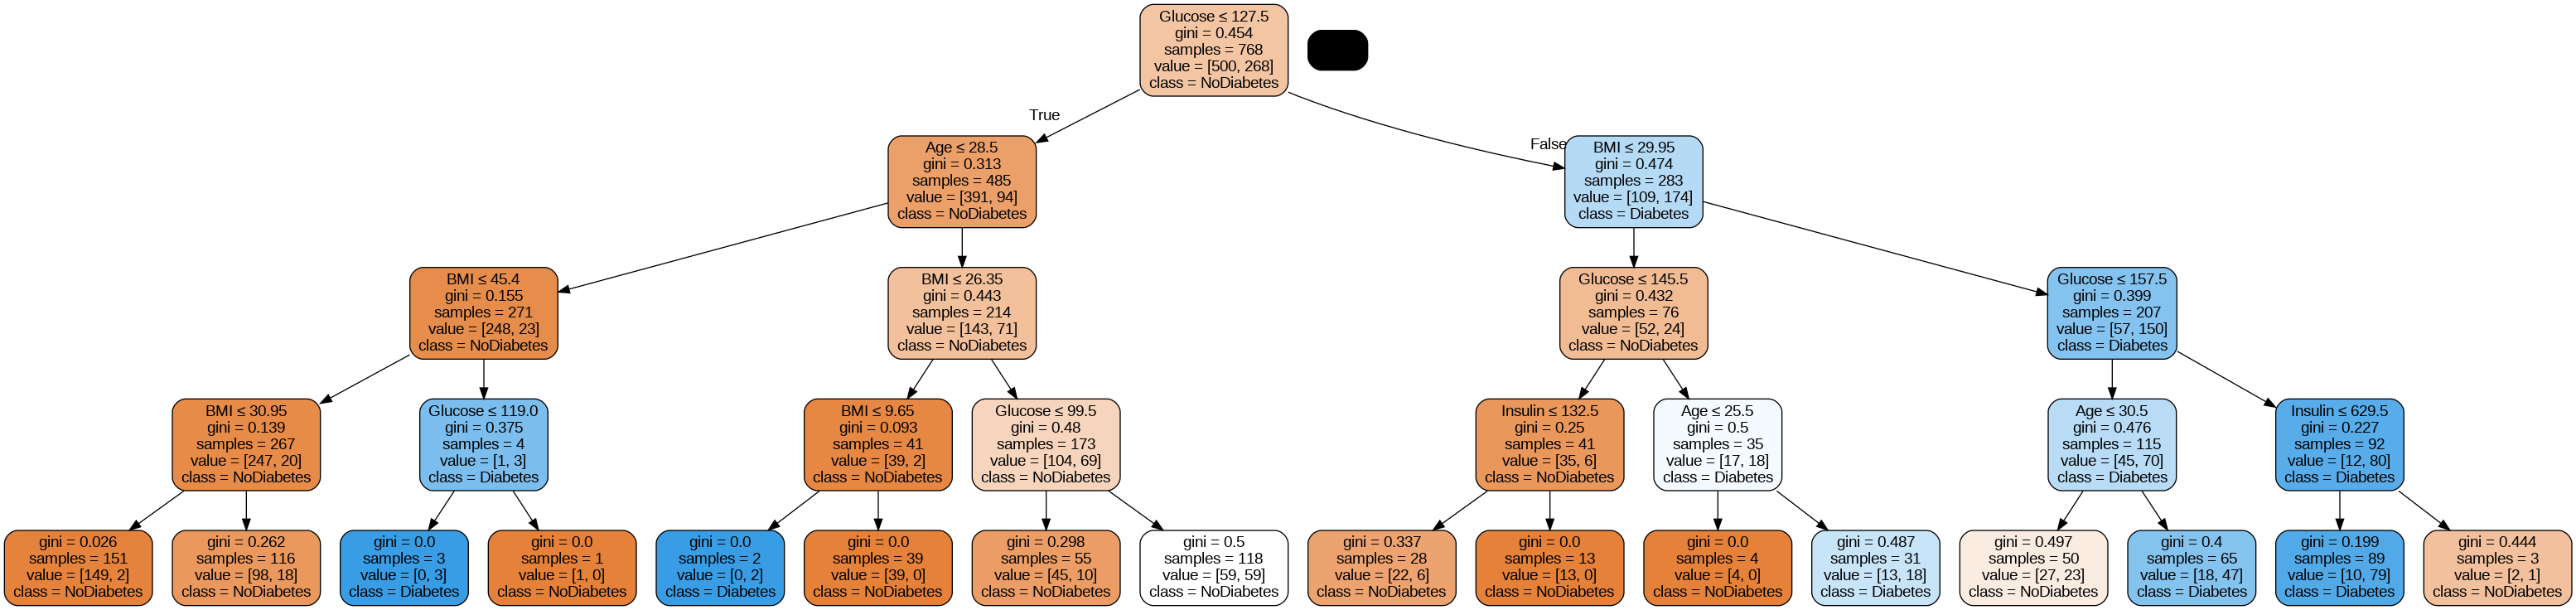

6.5 Evaluación del paciente en el árbol

In [ ]:
# Convertir el paciente a DataFrame para conservar nombres de variables
XP_df = pd.DataFrame([XP], columns=XD.columns)

# Pronosticar con el árbol
ydc_tree = mar.predict(XP_df)
print("Resultado del Árbol de Decisión:", ydc_tree)

# Interpretación del resultado
if ydc_tree == 1:
    print("El paciente presenta diabetes")
else:
    print("El paciente no presenta diabetes")

Resultado del Árbol de Decisión: [0]
El paciente no presenta diabetes


El árbol de decisión permite identificar reglas claras de clasificación, lo cual es una gran ventaja frente a otros modelos.

Además de medir el desempeño mediante la matriz de confusión, este enfoque facilita la interpretación de los resultados, ya que permite observar qué variables intervienen en cada decisión y cuáles umbrales separan a pacientes con y sin diabetes.

Desde el punto de vista del negocio, este modelo es muy valioso porque traduce el análisis en reglas comprensibles para el personal médico o administrativo.

**7. Modelo K-Means**

7.1 Construcción del modelo

In [ ]:
# Seleccionar variables de entrada y salida
XD = XDB.iloc[:,0:8]
yd = XDB.iloc[:,[8]]

# Fijar semilla para obtener resultados reproducibles
np.random.seed(42)

# Definir número de clusters
NC = 5

# Crear el modelo K-Means
mkm = KMeans(n_clusters=NC, random_state=42, n_init=10)

# Ajustar el modelo
mkm.fit(XD, yd.values.ravel())

# Mostrar centros de los clusters
Tabla = pd.DataFrame(mkm.cluster_centers_, columns=XD.columns)
display(Tabla)

# Obtener etiquetas de cluster para cada observación
ydp = mkm.labels_

# Contar número de datos por cluster
NDc = np.bincount(ydp)
print("El número de datos por cluster es:", NDc)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,4.394805,119.012987,67.400000,11.971429,0.644156,30.963636,0.421366,35.548052
1,4.047619,151.095238,72.142857,29.333333,305.833333,34.959524,0.558429,33.738095
2,3.821429,134.535714,72.650000,31.442857,169.542857,34.640714,0.554921,33.242857
3,2.732240,103.065574,68.857923,26.704918,79.661202,30.961749,0.476175,28.142077
4,3.111111,165.833333,73.444444,35.666667,548.833333,36.961111,0.660667,34.555556


El número de datos por cluster es: [385  42 140 183  18]


7.2 Probabilidades de diabetes por cluster

In [ ]:
# Crear una copia de la base y agregar la columna de cluster
XDB2 = XDB.copy()
XDB2["CLUSTER"] = ydp

# Contar número de pacientes con diabetes por cluster
NApr = XDB2.groupby("CLUSTER").agg({"Outcome": lambda x: (x == 1).sum()})

# Contar número de pacientes sin diabetes por cluster
NPrn = XDB2.groupby("CLUSTER").agg({"Outcome": lambda x: (x == 0).sum()})

# Mostrar cantidades
df2 = pd.DataFrame(np.column_stack((NApr, NPrn)), columns=["Diabetes", "NoDiabetes"])
display(df2)

# Calcular porcentajes por cluster
PDiab = NApr / (NApr + NPrn)
PNoDiab = NPrn / (NApr + NPrn)

DF2 = pd.DataFrame(np.column_stack((PDiab, PNoDiab)), columns=["Diabetes", "NoDiabetes"])
display(DF2)

,Diabetes,NoDiabetes
0,140,245
1,21,21
2,70,70
3,25,158
4,12,6


,Diabetes,NoDiabetes
0,0.363636,0.636364
1,0.500000,0.500000
2,0.500000,0.500000
3,0.136612,0.863388
4,0.666667,0.333333


7.3 Paciente evaluado en K-Means

In [ ]:
# Crear DataFrame del paciente con los nombres de las variables
nueva_persona_array = np.array([2,85,65,29,94,39.6,0.93,27])
nueva_persona = pd.DataFrame(nueva_persona_array.reshape(1, -1), columns=XD.columns)

# Determinar el cluster al que pertenece
ydp_paciente = mkm.predict(nueva_persona)
NCl = ydp_paciente[0]

print("La persona pertenece al cluster:", ydp_paciente)
print("El porcentaje de Diabetes para la nueva persona es:", PDiab.iloc[NCl].values[0])
print("El porcentaje de No Diabetes para la nueva persona es:", PNoDiab.iloc[NCl].values[0])

La persona pertenece al cluster: [3]
El porcentaje de Diabetes para la nueva persona es: 0.1366120218579235
El porcentaje de No Diabetes para la nueva persona es: 0.8633879781420765


7.4 Variables del cluster del paciente

In [ ]:
# Mostrar centro del cluster al que pertenece el paciente
print("Variables que caracterizan el cluster del paciente:")
display(Tabla.iloc[[NCl]])

Variables que caracterizan el cluster del paciente:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
3,2.73224,103.065574,68.857923,26.704918,79.661202,30.961749,0.476175,28.142077


7.5 Visualización de clusters

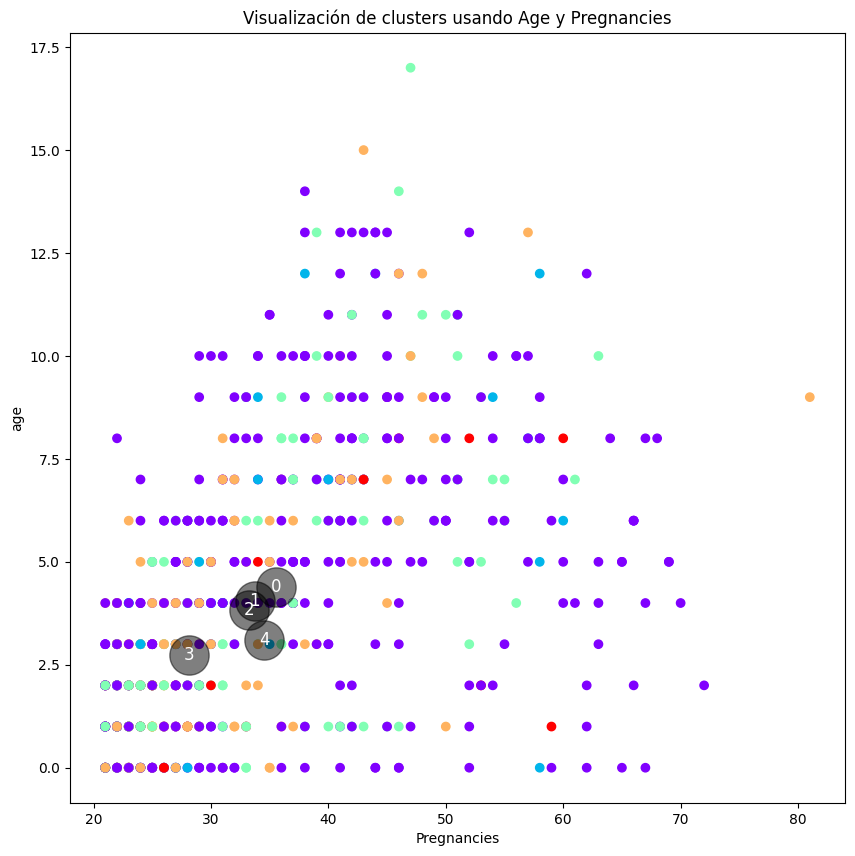

In [ ]:
# Extraer centros del modelo
centers = mkm.cluster_centers_

# Tomar dos variables para la gráfica: Age y Pregnancies
age = np.array(XD["Age"])
preg = np.array(XD["Pregnancies"])

# Graficar clusters
plt.figure(figsize=(10,10))
plt.scatter(age, preg, c=ydp, cmap="rainbow")

# Graficar centros de los clusters
plt.scatter(centers[:,7], centers[:,0], c="black", s=800, alpha=0.5)

plt.xlabel("Pregnancies")
plt.ylabel("age")
plt.title("Visualización de clusters usando Age y Pregnancies")

# Mostrar número de cluster en cada centro
for i, center in enumerate(centers):
    plt.text(center[7], center[0], str(i), color="white", fontsize=12, ha="center", va="center")

plt.show()

El modelo K-Means no es un clasificador supervisado, pero permite agrupar pacientes con características similares en diferentes segmentos.

A partir de estos grupos es posible calcular el porcentaje de pacientes con y sin diabetes dentro de cada cluster, lo que ayuda a identificar perfiles de riesgo.

Este enfoque es útil desde el punto de vista estratégico, ya que permite segmentar la población y diseñar acciones diferenciadas según el riesgo observado en cada grupo.

**8. Resumen del paciente evaluado**

Para el paciente evaluado con características
XDp = [2,85,65,29,94,39.6,0.93,27]

se obtiene:

Naive Bayes: clasificación según el modelo entrenado

Árbol de Decisión: clasificación según las reglas del árbol

K-Means: cluster al que pertenece y porcentaje de diabetes asociado a ese grupo

De esta manera se logra comparar el comportamiento de los tres enfoques frente al mismo individuo.

**9. Conclusión final**

Después de aplicar los tres modelos propuestos, se concluye que cada uno aporta valor desde una perspectiva diferente.

El modelo Naive Bayes ofrece una clasificación rápida y una interpretación estadística clara a partir de medias y desviaciones por categoría. Sin embargo, su capacidad explicativa frente al proceso de decisión es más limitada.

El modelo de Árbol de Decisión resulta especialmente útil porque, además de ofrecer un buen desempeño en términos de exactitud y clasificación, permite interpretar con claridad las reglas que conducen a la decisión. Esto representa una ventaja importante en el sector salud, ya que facilita explicar por qué un paciente fue clasificado en determinada categoría y apoya la toma de decisiones clínicas o administrativas.

Por su parte, el modelo K-Means no clasifica directamente la diabetes, pero sí permite segmentar a los pacientes en grupos homogéneos y estimar el porcentaje de riesgo de diabetes dentro de cada cluster. Esto puede ser muy útil para diseñar estrategias de seguimiento, prevención o priorización de pacientes.

En términos de recomendación, el modelo que se considera más apropiado para este problema es el Árbol de Decisión, debido a que combina un buen desempeño con una alta capacidad de interpretación. Desde el criterio de negocio, esto es fundamental porque un modelo en salud no solo debe clasificar adecuadamente, sino también permitir comprender y justificar sus resultados.

Por lo tanto, se recomienda usar el Árbol de Decisión como modelo principal, y complementar el análisis con K-Means para segmentación de pacientes y con Naive Bayes como modelo comparativo de referencia.